In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_url = 'https://raw.githubusercontent.com/AhmadZahran1011/AhmadZahran_2411532004_ML2526/refs/heads/main/praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [3]:
feature_cols = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']
X = df[feature_cols]
y = df.diagnosis

In [4]:
print(X.shape)
print(y.shape)

(569, 5)
(569,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# instantiate model
logreg = LogisticRegression(max_iter=5000)

# fit model
logreg.fit(X_train, y_train)

# prediksi
y_pred = logreg.predict(X_test)

# evaluasi
print("Accuracy tanpa scaling:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy tanpa scaling: 0.9298245614035088
Confusion Matrix:
[[40  3]
 [ 5 66]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91        43
           1       0.96      0.93      0.94        71

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



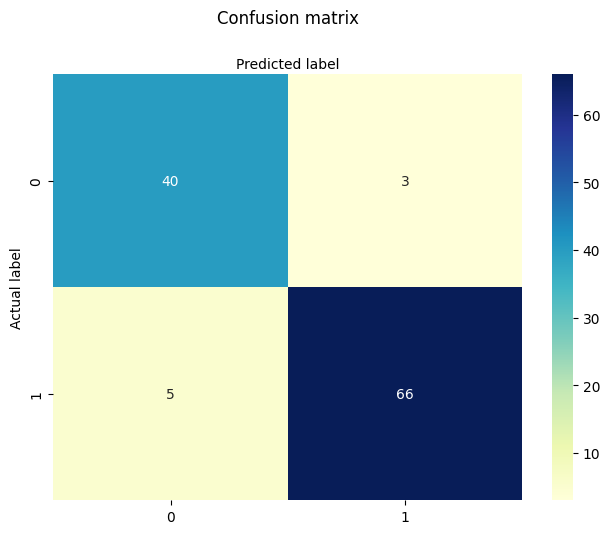

In [7]:
# membuat confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)

class_names = [0,1]  # name of classes
fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

ax.xaxis.set_label_position("top")
plt.tight_layout()

plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler++

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# instantiate model
logreg = LogisticRegression(max_iter=5000)

# fit model
logreg.fit(X_train_scaled, y_train)

# prediksi
y_pred = logreg.predict(X_test_scaled)

# evaluasi
print("Accuracy dengan scaling:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy dengan scaling: 0.9385964912280702
Confusion Matrix:
[[39  4]
 [ 3 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



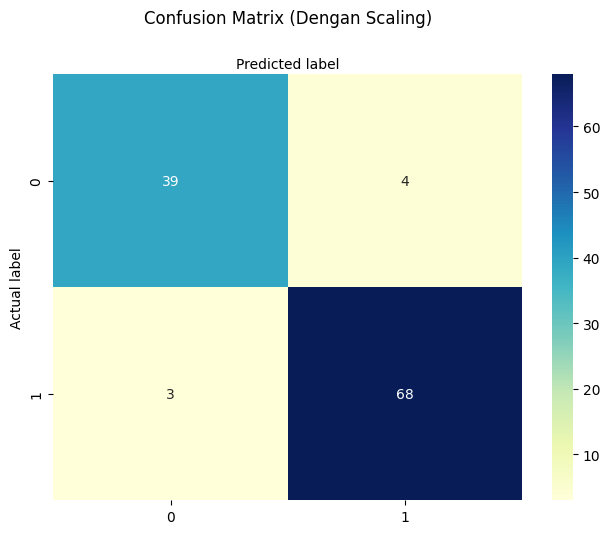

In [10]:
# membuat confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)

class_names = [0,1]  # nama kelas
fig, ax = plt.subplots()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# membuat heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

ax.xaxis.set_label_position("top")
plt.tight_layout()

plt.title('Confusion Matrix (Dengan Scaling)', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()

In [11]:
# instantiate model
logreg = LogisticRegression()

# fit model
logreg.fit(X_train, y_train)

# probabilitas prediksi
y_prob = logreg.predict_proba(X_test)[:,1]

# percobaan threshold
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    print("Threshold:", t)
    print("Accuracy:", accuracy_score(y_test, y_pred))

Threshold: 0.3
Accuracy: 0.9210526315789473
Threshold: 0.5
Accuracy: 0.9298245614035088
Threshold: 0.7
Accuracy: 0.9385964912280702
